## HD5750 

Spectral analysis of HD5750 from the fits data and interpolator flux predicted values 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits

In [2]:
path_5750 = "../FITS_data/5750.fits"

In [3]:
with fits.open(path_5750) as data_5750:
    data_5750.info()


Filename: ../FITS_data/5750.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     107   (15011,)   float32   
  1  c0101110027    1 ImageHDU       143   (3062, 1, 4)   float32   
  2  c0210160091    1 ImageHDU       143   (3059, 1, 4)   float32   
  3  c0210210034    1 ImageHDU       143   (3059, 1, 4)   float32   
  4  c0210240032    1 ImageHDU       143   (3059, 1, 4)   float32   
  5  a0101110027    1 ImageHDU       107   (3062, 1, 4)   float32   
  6  a0210160091    1 ImageHDU       107   (3059, 1, 4)   float32   
  7  a0210210034    1 ImageHDU       107   (3059, 1, 4)   float32   
  8  a0210240032    1 ImageHDU       107   (3059, 1, 4)   float32   


In [4]:
data_5750 = fits.open(path_5750)

In [5]:
hdr = data_5750[0].header

crval = hdr["CRVAL1"]      # start value of the wavelength pixel
cdelt = hdr["CDELT1"]      # step value of the wavelength pixel

print(cdelt)

0.4


In [6]:
n_wave_points = len(data_5750[0].data)
n_wave_points

15011

In [7]:
wavelengths = crval + cdelt * np.arange(n_wave_points)

flux = data_5750[0].data

flux

array([7.477026e-01, 7.218224e-01, 6.585574e-01, ..., 1.000000e-04,
       1.000000e-04, 1.000000e-04], dtype=float32)

Plotting the flux-wavelength continuum for HD5750:

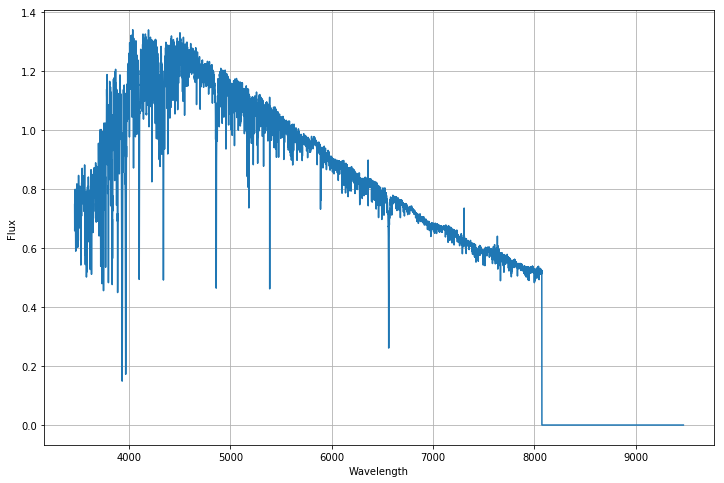

In [8]:
plt.figure(figsize = (12, 8))
plt.plot(wavelengths,flux)
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.grid()
plt.show()

Plotting the wavelength - flux continuum for HD5750 using the interpolator pipeline : 

In [9]:
from sklearn.externals import joblib

In [10]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [11]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7

In [12]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [13]:
pred = InterpolateSpectrum(6330,4.21,-0.42)

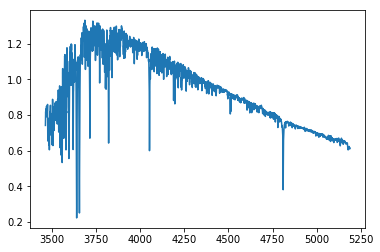

In [14]:
plt.plot(wavelengths[:4306],pred[0,:])

#### Comparing the Interpolator flux curve and CFLIB Fits flux curve : 

Also equalizing the wavelength coverage for both the CFLIB flux data (original and interpolated) :

7339.5
9686


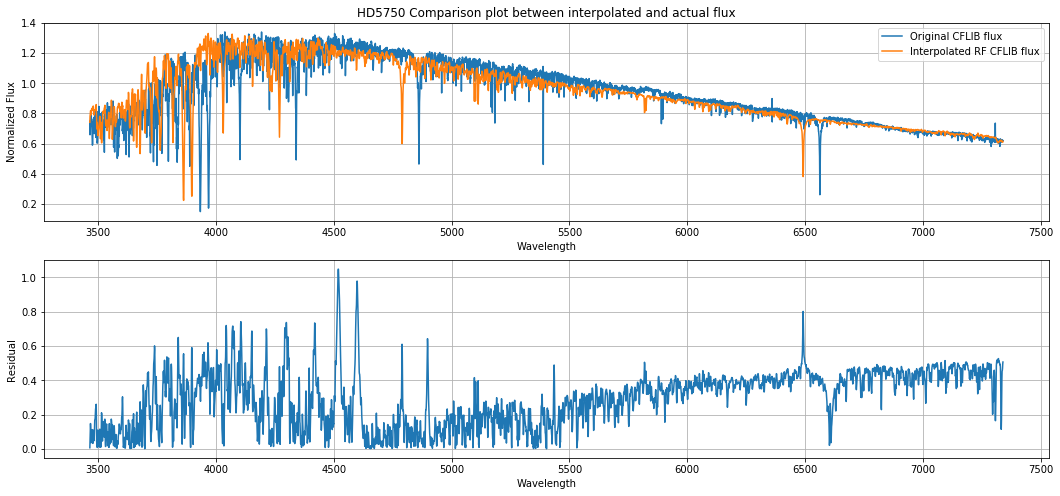

In [15]:
with fits.open(path_5750) as data_5750:
    hdr = data_5750[0].header
    
    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wave_points = len(data_5750[0].data)          # total number of wavelength pixels

    flux = data_5750[0].data                     # Flux array for the fits cflib data
    
    wavelength = crval + cdelt * np.arange(n_wave_points)         # setting up the wavelength axis for the CFLIB original

    int_wavelength = crval + 0.9 * np.arange(n_wave_points)[:4306]  # wavelength axis for Interpolated CFLIB

    # Looking for the last value of the interpolated flux to equalize the wavelength coverage of interpolated flux and original flux
    print(int_wavelength[-1])
    # Looking for the index of the wavelength nearest to the last wavelength of the interpolated flux
    for i in range(len(wavelength)):
        if 7339 < wavelength[i] < 7339.8:
            print(i)


    fig, axes = plt.subplots(2, 1, figsize = (18, 8))
    
    axes[0].plot(wavelength[:9686], flux[:9686], label = "Original CFLIB flux")
    axes[0].plot(int_wavelength, pred[0,:], label = "Interpolated RF CFLIB flux")
    axes[0].set_title("HD5750 Comparison plot between interpolated and actual flux")
    axes[0].set_xlabel("Wavelength")
    axes[0].set_ylabel("Normalized Flux")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(int_wavelength, np.abs(flux[:4306] - pred[0,:]))
    axes[1].set_xlabel("Wavelength")
    axes[1].set_ylabel("Residual")
    axes[1].grid(True)

    plt.show()

Checking if the interpolated flux is normalized at 5550 A : 

In [16]:
for i in range(len(int_wavelength)):
    if pred[0,:][i] == 1:
        print("The interpolated flux is normalized at wavelength : {} A".format(int_wavelength[i]))
        print("The index of the normalizing wavelength : {}".format(i))

The interpolated flux is normalized at wavelength : 5479.2 A
The index of the normalizing wavelength : 2238


### Renormalizing the flux at 5550 A: 

Finding the index of the 5550 A wavelength :


In [17]:
for i in range(len(int_wavelength)):
    if int_wavelength[i]//1 == 5550:
        print(int_wavelength[i])
        print(i)

5550.3
2317


In [18]:
normalized_int_flux = pred[0,:]/pred[0,:][2317]

normalized_int_flux

array([0.75703569, 0.80009301, 0.81141828, ..., 0.62261649, 0.6222467 ,
       0.62842221])

In [19]:
normalized_int_flux[2317]

1.0

Renormalizing the fits flux : 

In [20]:
for i in range(len(wavelength[:9686])):
    if wavelength[i]//1 == 5550:
        print(wavelength[i])

5550.200000000001
5550.6


In [21]:
for i in range(len(wavelength[:9686])):
    if wavelength[i] == 5550.200000000001:
        print(wavelength[i])
        print(i)


5550.200000000001
5213


In [25]:
# Renormalizing the original flux now :
normalized_org_flux = flux/flux[5213]

normalized_org_flux

array([7.2765392e-01, 7.0246768e-01, 6.4089906e-01, ..., 9.7318625e-05,
       9.7318625e-05, 9.7318625e-05], dtype=float32)

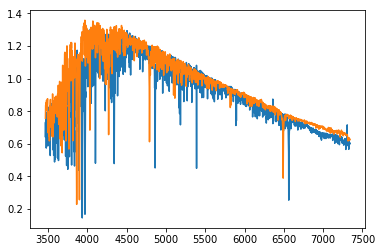

In [26]:
plt.plot(wavelength[:9686], normalized_org_flux[:9686], label = "Original CFLIB flux")
plt.plot(int_wavelength, normalized_int_flux, label = "Interpolated RF CFLIB flux")

Renormalizing didn't shift the curves for HD5750. 